Before proceeding with things, I want to know for sure the functionality of a time distributed layer. What does this layer do exactly, how to make sense out of this. The most commno encounter with this is in Numerical Machine Translation problems, where the Dense layer with softmax actiavation is wrapped in a TimeDistributed layer as the decoder outputs are a time series.

But what exactly happens here?

In [1]:
import tensorflow as tf
import numpy as np

2025-07-11 11:14:17.587564: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-11 11:14:17.624203: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-07-11 11:14:17.624227: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-07-11 11:14:17.625049: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-11 11:14:17.631221: I tensorflow/core/platform/cpu_feature_guar

In [2]:
# Below is the keras example - It cosiders 32 video samples, each video is 10 frames, each frame is a 128,128,3 RGB image.

# For the time distributed layer - The input should be at least 3D, and the index = 1 should correspond to the time dimension

inputs = tf.keras.layers.Input(shape = (10,128,128,3), batch_size = 32)

conv2D_layer = tf.keras.layers.Conv2D(64, (3,3))

output = tf.keras.layers.TimeDistributed(conv2D_layer)(inputs)

2025-07-11 11:14:19.424581: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 31134 MB memory:  -> device: 0, name: Tesla V100S-PCIE-32GB, pci bus id: 0000:86:00.0, compute capability: 7.0


In [3]:
example_model1 = tf.keras.models.Model(inputs = inputs, outputs = output)

In [4]:
example_model1.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(32, 10, 128, 128, 3)]   0         
                                                                 
 time_distributed (TimeDist  (32, 10, 126, 126, 64)    1792      
 ributed)                                                        
                                                                 
Total params: 1792 (7.00 KB)
Trainable params: 1792 (7.00 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


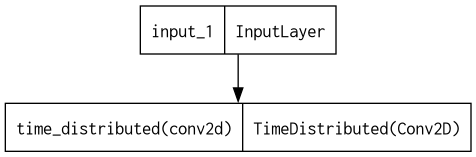

In [5]:
tf.keras.utils.plot_model(example_model1)

In [6]:
# there's 3 layers and then the bias
(3*3*64) * 3 + 64

1792

In [7]:
inputs.shape

TensorShape([32, 10, 128, 128, 3])

In [8]:
output.shape

TensorShape([32, 10, 126, 126, 64])

In [9]:
# can we do the same architecture but without the timedistributed layer?

In [10]:
inputs_example2 = tf.keras.layers.Input(shape = (10,128,128,3), batch_size = 32)

conv2D_layer = tf.keras.layers.Conv2D(64, (3,3))

output_output = conv2D_layer(inputs_example2)

In [11]:
output_output.shape

TensorShape([32, 10, 126, 126, 64])

In [12]:
example_model2 = tf.keras.models.Model(inputs = inputs_example2, outputs = output_output)

In [13]:
example_model2.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(32, 10, 128, 128, 3)]   0         
                                                                 
 conv2d_1 (Conv2D)           (32, 10, 126, 126, 64)    1792      
                                                                 
Total params: 1792 (7.00 KB)
Trainable params: 1792 (7.00 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


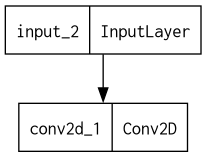

In [14]:
tf.keras.utils.plot_model(example_model2)

In [15]:
# Seems both these work -  should we train these models for a few epochs and see if we can get the same results?

In [16]:
# layer weights model 1

In [17]:
conv_layer_weights_ex1 = conv2D_layer.get_weights()

In [18]:
len(conv_layer_weights_ex1)

2

In [19]:
conv_layer_weights_ex1[0].shape, conv_layer_weights_ex1[1].shape

((3, 3, 3, 64), (64,))

In [20]:
# layer weights model 2

In [21]:
conv_layer_weights_ex2 = conv2D_layer.get_weights()

In [22]:
len(conv_layer_weights_ex2)

2

In [23]:
conv_layer_weights_ex2[0].shape, conv_layer_weights_ex2[1].shape

((3, 3, 3, 64), (64,))

In [24]:
# are these identical? since we are doing default initializers?
print(np.mean(conv_layer_weights_ex1[0] == conv_layer_weights_ex2[0]))
print(np.mean(conv_layer_weights_ex1[0] == conv_layer_weights_ex2[0]))

1.0
1.0


In [25]:
# generate some random values for input and output?

X_train = np.random.normal(loc=2, scale=3, size=(32, 10, 128, 128, 3))
y_train = np.random.random(size = (32, 10, 126, 126, 64))

In [26]:
X_train.shape

(32, 10, 128, 128, 3)

In [27]:
y_train.shape

(32, 10, 126, 126, 64)

In [28]:
# train the first model

# compile the model
example_model1.compile(optimizer = "adam", loss = 'mse', metrics = ['mae'])

In [29]:
example_model1.fit(X_train, y_train, epochs = 20)

Epoch 1/20


2025-07-11 11:14:27.034620: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8907
2025-07-11 11:14:28.158811: I external/local_xla/xla/service/service.cc:168] XLA service 0x148dccf32d00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-07-11 11:14:28.158836: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): Tesla V100S-PCIE-32GB, Compute Capability 7.0
2025-07-11 11:14:28.163965: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1752250468.266115 4062882 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1/1 [==============================] - 3s 3s/step - loss: 1.6097 - mae: 1.0209
Epoch 2/20
1/1 [==============================] - 0s 340ms/step - loss: 1.5277 - mae: 0.9922
Epoch 3/20
1/1 [==============================] - 0s 329ms/step - loss: 1.4511 - mae: 0.9649
Epoch 4/20
1/1 [==============================] - 0s 340ms/step - loss: 1.3798 - mae: 0.9392
Epoch 5/20
1/1 [==============================] - 0s 334ms/step - loss: 1.3136 - mae: 0.9149
Epoch 6/20
1/1 [==============================] - 0s 330ms/step - loss: 1.2522 - mae: 0.8920
Epoch 7/20
1/1 [==============================] - 0s 355ms/step - loss: 1.1955 - mae: 0.8705
Epoch 8/20
1/1 [==============================] - 0s 356ms/step - loss: 1.1432 - mae: 0.8505
Epoch 9/20
1/1 [==============================] - 0s 348ms/step - loss: 1.0950 - mae: 0.8317
Epoch 10/20
1/1 [==============================] - 0s 356ms/step - loss: 1.0506 - mae: 0.8141
Epoch 11/20
1/1 [==============================] - 0s 342ms/step - loss: 1.0098 - m

In [30]:
# weights of the trained first model for the conv layer
traied_conv_layer_weights_ex1 = example_model1.layers[1].get_weights()

In [31]:
traied_conv_layer_weights_ex1[0].shape, traied_conv_layer_weights_ex1[1].shape

((3, 3, 3, 64), (64,))

In [32]:
# train the secons model

# compile the model
example_model2.compile(optimizer = "adam", loss = 'mse', metrics = ['mae'])

In [33]:
example_model2.fit(X_train, y_train, epochs = 20)

Epoch 1/20
1/1 [==============================] - 2s 2s/step - loss: 1.4228 - mae: 0.9521
Epoch 2/20
1/1 [==============================] - 0s 331ms/step - loss: 1.3533 - mae: 0.9269
Epoch 3/20
1/1 [==============================] - 0s 330ms/step - loss: 1.2887 - mae: 0.9031
Epoch 4/20
1/1 [==============================] - 0s 332ms/step - loss: 1.2289 - mae: 0.8808
Epoch 5/20
1/1 [==============================] - 0s 333ms/step - loss: 1.1736 - mae: 0.8599
Epoch 6/20
1/1 [==============================] - 0s 350ms/step - loss: 1.1225 - mae: 0.8403
Epoch 7/20
1/1 [==============================] - 0s 348ms/step - loss: 1.0753 - mae: 0.8220
Epoch 8/20
1/1 [==============================] - 0s 358ms/step - loss: 1.0318 - mae: 0.8048
Epoch 9/20
1/1 [==============================] - 1s 591ms/step - loss: 0.9916 - mae: 0.7887
Epoch 10/20
1/1 [==============================] - 1s 593ms/step - loss: 0.9545 - mae: 0.7737
Epoch 11/20
1/1 [==============================] - 0s 340ms/step - loss:

In [34]:
# weights of the trained first model for the conv layer
traied_conv_layer_weights_ex2 = example_model2.layers[1].get_weights()

In [35]:
traied_conv_layer_weights_ex2[0].shape, traied_conv_layer_weights_ex2[1].shape

((3, 3, 3, 64), (64,))

In [36]:
# are these weights the same?
np.mean(traied_conv_layer_weights_ex2[0] == traied_conv_layer_weights_ex1[0])

0.0

In [37]:
# none of these are the same, I think this is to be expected. 

In [38]:
# traied_conv_layer_weights_ex2[0]

In [39]:
# but can we do a get weights and set weights from model 1 to 2?

In [40]:
example_model2.set_weights(example_model1.get_weights())

In [41]:
# so yes, this can be done

In [42]:
np.mean(example_model2.get_weights()[0] == traied_conv_layer_weights_ex1[0])

1.0

In [43]:
# What I want to know exactly is how does the back prop work in these two instances? Maybe need to learn this with a simpler example.

In [44]:
# Some examples I believe will help are as follows

In [45]:
# Machine learning mastery

In [46]:
# Imagine a situation where we give as input [0.0, 0.2 ,0.4, 0.6 ,0.8] at each time step and expect the sequence to be returned

In [47]:
length = 5
seq = np.array([i/float(length) for i in range(length)])
seq

array([0. , 0.2, 0.4, 0.6, 0.8])

In [48]:
# but we try to od this as a piece-wise problem 

# X Y
# 0.0 0.0
# 0.2 0.2
# 0.4 0.4
# 0.6 0.6
# 0.8 0.8

# And we are going to solve this as a seq-2-seq problem

In [49]:
X = seq.reshape(5,1,1)
Y = seq.reshape(5,1)

In [50]:
X.shape, Y.shape

((5, 1, 1), (5, 1))

In [51]:
# Define LSTM configuration

n_neurons = length
n_batch = length
n_epochs = 1000
input = tf.keras.layers.Input(shape = (1,1))
lstm_layer = tf.keras.layers.LSTM(n_neurons)
lstm_out = lstm_layer(input)
dense_layer = tf.keras.layers.Dense(1)
dense_out = dense_layer(lstm_out)

one_to_one_model = tf.keras.models.Model(inputs = input, outputs = dense_out)
one_to_one_model.summary()

Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 1, 1)]            0         
                                                                 
 lstm (LSTM)                 (None, 5)                 140       
                                                                 
 dense (Dense)               (None, 1)                 6         
                                                                 
Total params: 146 (584.00 Byte)
Trainable params: 146 (584.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [52]:
# compile model
one_to_one_model.compile(optimizer = 'adam', loss = 'mse', metrics = ['mae'])

In [53]:
one_to_one_model.fit(X,Y, epochs = n_epochs)

Epoch 1/1000
1/1 [==============================] - 2s 2s/step - loss: 0.2698 - mae: 0.4243
Epoch 2/1000
1/1 [==============================] - 0s 11ms/step - loss: 0.2680 - mae: 0.4230
Epoch 3/1000
1/1 [==============================] - 0s 9ms/step - loss: 0.2661 - mae: 0.4216
Epoch 4/1000
1/1 [==============================] - 0s 8ms/step - loss: 0.2643 - mae: 0.4203
Epoch 5/1000
1/1 [==============================] - 0s 8ms/step - loss: 0.2625 - mae: 0.4189
Epoch 6/1000
1/1 [==============================] - 0s 8ms/step - loss: 0.2607 - mae: 0.4176
Epoch 7/1000
1/1 [==============================] - 0s 9ms/step - loss: 0.2589 - mae: 0.4162
Epoch 8/1000
1/1 [==============================] - 0s 10ms/step - loss: 0.2571 - mae: 0.4149
Epoch 9/1000
1/1 [==============================] - 0s 8ms/step - loss: 0.2553 - mae: 0.4135
Epoch 10/1000
1/1 [==============================] - 0s 8ms/step - loss: 0.2536 - mae: 0.4122
Epoch 11/1000
1/1 [==============================] - 0s 8ms/step - l

In [54]:
one_to_one_model.predict(X)

1/1 [==============================] - 0s 258ms/step


array([[0.03380468],
       [0.20154391],
       [0.39516175],
       [0.59574574],
       [0.78598547]], dtype=float32)

In [55]:
# Since the number of parameters in the network bother us - let's compute these values

# For the LSTM, the number of params = 140, since this has 4 gates, each gate has 140/4 = 35 params. Now where do these 35 come from?

# for a simple RNN, output/hiddenstate is a function of 

# h_t = f(W*x_t + U*h_(t-1) + b)

# now what are the dimensions of these? x_t is the dimensions of features at timestep t, suppose this dimension is d (ideally d*1 I believe), then W should be some_dimension*d, and h_t is some_dimension*1. Therefore U is some_dimension*some_dimension, and b is some_dimension*1. Here some dimension is the number of hidden neurons (no.of neurons in the LSTM layer).

# Therefore in our case, the number of parameters in each gate would be = some_dimension*d (for W) + some_dimension*some_dimension (for U) + some_dimension*1 (for b) = 5*1 + 5*5 + 5 = 35

In [56]:
# now he does a many to one model, basically predicts everything in one go, but uses a Dense layer for this

X = seq.reshape(1,5,1)
Y = seq.reshape(1,5)

In [57]:
X.shape, Y.shape

((1, 5, 1), (1, 5))

In [58]:
mo_input = tf.keras.layers.Input(shape = (5,1))

mo_lstm = tf.keras.layers.LSTM(length)

mo_out = mo_lstm(mo_input)

mo_dense = tf.keras.layers.Dense(5)

mo_dense_out = mo_dense(mo_out)

many_to_one_model = tf.keras.models.Model(inputs = mo_input, outputs = mo_dense_out)

In [59]:
many_to_one_model.summary()

Model: "model_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 5, 1)]            0         
                                                                 
 lstm_1 (LSTM)               (None, 5)                 140       
                                                                 
 dense_1 (Dense)             (None, 5)                 30        
                                                                 
Total params: 170 (680.00 Byte)
Trainable params: 170 (680.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [60]:
# Notice he does not do a return sequnce = True in here

In [61]:
# compile this model
many_to_one_model.compile(optimizer = "adam", loss = "mse", metrics = ['mae'])

In [62]:
many_to_one_model.fit(X, Y, epochs = 500)

Epoch 1/500
1/1 [==============================] - 1s 1s/step - loss: 0.2690 - mae: 0.4149
Epoch 2/500
1/1 [==============================] - 0s 11ms/step - loss: 0.2670 - mae: 0.4135
Epoch 3/500
1/1 [==============================] - 0s 11ms/step - loss: 0.2650 - mae: 0.4122
Epoch 4/500
1/1 [==============================] - 0s 10ms/step - loss: 0.2631 - mae: 0.4108
Epoch 5/500
1/1 [==============================] - 0s 10ms/step - loss: 0.2612 - mae: 0.4094
Epoch 6/500
1/1 [==============================] - 0s 9ms/step - loss: 0.2593 - mae: 0.4079
Epoch 7/500
1/1 [==============================] - 0s 10ms/step - loss: 0.2575 - mae: 0.4065
Epoch 8/500
1/1 [==============================] - 0s 10ms/step - loss: 0.2556 - mae: 0.4050
Epoch 9/500
1/1 [==============================] - 0s 10ms/step - loss: 0.2538 - mae: 0.4036
Epoch 10/500
1/1 [==============================] - 0s 10ms/step - loss: 0.2520 - mae: 0.4021
Epoch 11/500
1/1 [==============================] - 0s 10ms/step - loss:

In [63]:
many_to_one_model.predict(X)

1/1 [==============================] - 0s 239ms/step


array([[5.9604645e-08, 1.9999069e-01, 3.9989948e-01, 5.9977996e-01,
        7.9998893e-01]], dtype=float32)

In [64]:
# Now many-to-many model - This uses a time distributed layer

# Few thinsg in the time distributed layer
# - The inputs should be at least 3D, time dimension is 1
# - The output of this will be a 3D matrix

# so need to reshape Y

Y = seq.reshape(1, 5, 1)

In [65]:
X.shape, Y.shape

((1, 5, 1), (1, 5, 1))

In [66]:
# define the model
mm_input = tf.keras.layers.Input(shape = (5,1))

mm_lstm = tf.keras.layers.LSTM(length, return_sequences = True)

mm_out = mm_lstm(mm_input)

# time distributed dense layer
td_dense = tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(1))

td_dense_out = td_dense(mm_out)

mm_model = tf.keras.models.Model(inputs = mm_input, outputs = td_dense_out)

mm_model.summary()

Model: "model_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_5 (InputLayer)        [(None, 5, 1)]            0         
                                                                 
 lstm_2 (LSTM)               (None, 5, 5)              140       
                                                                 
 time_distributed_1 (TimeDi  (None, 5, 1)              6         
 stributed)                                                      
                                                                 
Total params: 146 (584.00 Byte)
Trainable params: 146 (584.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [67]:
mm_model.compile(optimizer = "adam", loss = 'mse', metrics = ['mae'])

In [68]:
mm_model.fit(X, Y, epochs = 1000)

Epoch 1/1000
1/1 [==============================] - 1s 1s/step - loss: 0.1438 - mae: 0.3135
Epoch 2/1000
1/1 [==============================] - 0s 11ms/step - loss: 0.1414 - mae: 0.3111
Epoch 3/1000
1/1 [==============================] - 0s 10ms/step - loss: 0.1391 - mae: 0.3086
Epoch 4/1000
1/1 [==============================] - 0s 9ms/step - loss: 0.1367 - mae: 0.3062
Epoch 5/1000
1/1 [==============================] - 0s 8ms/step - loss: 0.1344 - mae: 0.3038
Epoch 6/1000
1/1 [==============================] - 0s 8ms/step - loss: 0.1322 - mae: 0.3014
Epoch 7/1000
1/1 [==============================] - 0s 8ms/step - loss: 0.1299 - mae: 0.2990
Epoch 8/1000
1/1 [==============================] - 0s 10ms/step - loss: 0.1277 - mae: 0.2965
Epoch 9/1000
1/1 [==============================] - 0s 10ms/step - loss: 0.1254 - mae: 0.2941
Epoch 10/1000
1/1 [==============================] - 0s 10ms/step - loss: 0.1232 - mae: 0.2917
Epoch 11/1000
1/1 [==============================] - 0s 11ms/step

In [69]:
mm_model.predict(X)

1/1 [==============================] - 0s 248ms/step


array([[[0.04883283],
        [0.18872234],
        [0.37703848],
        [0.5940349 ],
        [0.81170285]]], dtype=float32)

In [70]:
# This is what he has. Now what if we do not use the TD layer?

In [71]:
# define the model
mm_input = tf.keras.layers.Input(shape = (5,1))

mm_lstm = tf.keras.layers.LSTM(length, return_sequences = True)

mm_out = mm_lstm(mm_input)

# time distributed dense layer
td_dense = tf.keras.layers.Dense(1)

td_dense_out = td_dense(mm_out)

mm_model = tf.keras.models.Model(inputs = mm_input, outputs = td_dense_out)

mm_model.summary()

Model: "model_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_6 (InputLayer)        [(None, 5, 1)]            0         
                                                                 
 lstm_3 (LSTM)               (None, 5, 5)              140       
                                                                 
 dense_3 (Dense)             (None, 5, 1)              6         
                                                                 
Total params: 146 (584.00 Byte)
Trainable params: 146 (584.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [72]:
# notice that it still seem to work

In [73]:
mm_out.shape

TensorShape([None, 5, 5])

In [74]:
# Now what if the output sequence have a different dimension? like let's say the number of time steps is now different?

In [75]:
# Let's study this problem later

CNN-LSTM example at https://medium.com/smileinnovation/how-to-work-with-time-distributed-data-in-a-neural-network-b8b39aa4ce00

In [76]:
# Develop the said model here - He seems to just give the model architecture and there is no worked out example, but seems the idea is clear enough

# Also verify the learned weights are the same for all the layers that are passed through the TD layers

In [77]:
# Let's assume we have 5 224*224*3 images as the input sequence. Let's pass this though a time distributed layer - note the dimension 1 is the time dimension (axis 1)
cnn_input = tf.keras.layers.Input(shape = (5, 224, 224, 3))

# pass this through the TD layer and build the CNN model for extracting features
TD_conv1 = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv2D(64, (3,3), strides  = (2,2), padding = 'same', activation = 'relu'))

TD_conv1_out = TD_conv1(cnn_input)

# add the second conv layer

TD_conv2 = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv2D(64, (3,3), strides  = (2,2), padding = 'same', activation = 'relu'))

TD_conv2_out = TD_conv2(TD_conv1_out)

# Add a max pooling layer

TD_maxpool1 = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPooling2D((2,2), strides  = (2,2)))

TD_maxpool1_out = TD_maxpool1(TD_conv2_out)

# Add another conv2D

TD_conv3 = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv2D(128, (3,3), strides  = (2,2), padding = 'same', activation = 'relu'))

TD_conv3_out = TD_conv3(TD_maxpool1_out)

# another max pool layer
Td_maxpool2 = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPooling2D((2,2), strides  = (2,2)))

Td_maxpool2_out = Td_maxpool2(TD_conv3_out)

# Add a flatten layer
flatten_layer = tf.keras.layers.Flatten()

flatten_out = flatten_layer(Td_maxpool2_out)

# Add a dense layer
dense_layer = tf.keras.layers.Dense(10)

dense_out = dense_layer(flatten_out)

In [78]:
TD_conv1_out.shape, TD_conv2_out.shape, TD_conv3_out.shape, dense_out.shape

(TensorShape([None, 5, 112, 112, 64]),
 TensorShape([None, 5, 56, 56, 64]),
 TensorShape([None, 5, 14, 14, 128]),
 TensorShape([None, 10]))

In [79]:
# build the model here

cnn_TD_model = tf.keras.Model(inputs = cnn_input, outputs = dense_out)

In [80]:
cnn_TD_model.summary()

Model: "model_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_7 (InputLayer)        [(None, 5, 224, 224, 3)   0         
                             ]                                   
                                                                 
 time_distributed_2 (TimeDi  (None, 5, 112, 112, 64)   1792      
 stributed)                                                      
                                                                 
 time_distributed_3 (TimeDi  (None, 5, 56, 56, 64)     36928     
 stributed)                                                      
                                                                 
 time_distributed_4 (TimeDi  (None, 5, 28, 28, 64)     0         
 stributed)                                                      
                                                                 
 time_distributed_5 (TimeDi  (None, 5, 14, 14, 128)    7385

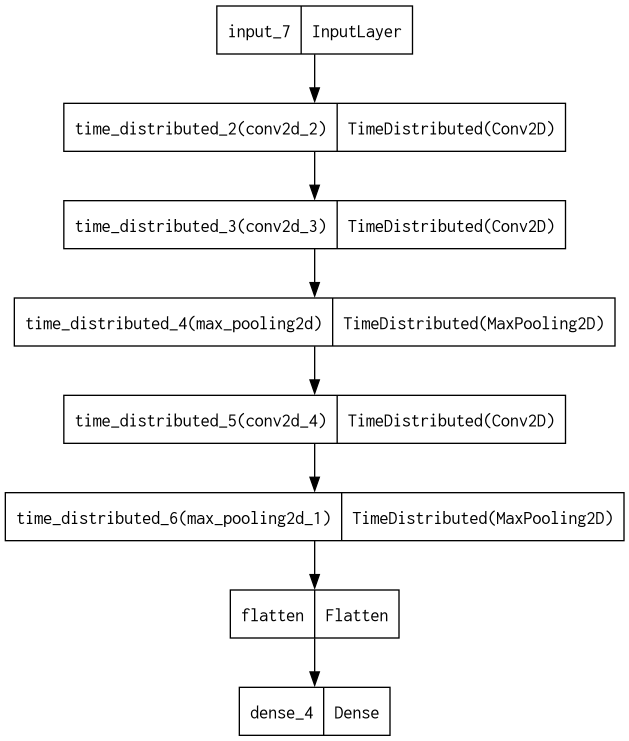

In [81]:
tf.keras.utils.plot_model(cnn_TD_model)

In [82]:
from tensorflow.keras.layers import TimeDistributed, Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.models import Sequential

In [83]:
model = Sequential()
# input, with 64 convolutions for 5 images
# that have (224, 224, 3) shape
model.add(TimeDistributed(Conv2D(64, (3,3), padding='same', strides=(2,2), activation='relu'), input_shape = (5, 224, 224, 3)))
model.add(
    TimeDistributed( 
        Conv2D(64, (3,3), 
            padding='same', strides=(2,2), activation='relu')
    )
)
model.add(
    TimeDistributed(
        MaxPooling2D((2,2), strides=(2,2))
    )
)
# Second conv, 128
model.add(
    TimeDistributed(
        Conv2D(128, (3,3),
            padding='same', strides=(2,2), activation='relu')
    )
)
model.add(
    TimeDistributed( 
        Conv2D(128, (3,3),
            padding='same', strides=(2,2), activation='relu')
    )
)
model.add(
    TimeDistributed(
        MaxPooling2D((2,2), strides=(2,2))
    )
)
## and so on with 512, 1024... 
## ...
# then we can use Flatten to reduce dimension to 1
model.add(Flatten())
## and then... merge the entire outputs to
## be able to use Dense(), and make predictions...
model.add(Dense(10))

model.add(Dense(1))

In [84]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 time_distributed_7 (TimeDi  (None, 5, 112, 112, 64)   1792      
 stributed)                                                      
                                                                 
 time_distributed_8 (TimeDi  (None, 5, 56, 56, 64)     36928     
 stributed)                                                      
                                                                 
 time_distributed_9 (TimeDi  (None, 5, 28, 28, 64)     0         
 stributed)                                                      
                                                                 
 time_distributed_10 (TimeD  (None, 5, 14, 14, 128)    73856     
 istributed)                                                     
                                                                 
 time_distributed_11 (TimeD  (None, 5, 7, 7, 128)      1

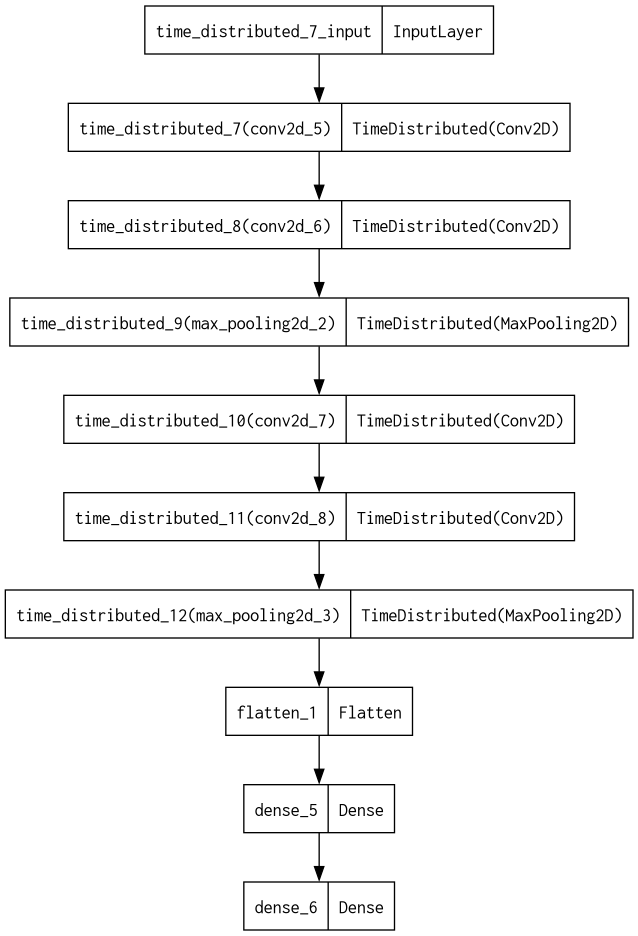

In [85]:
tf.keras.utils.plot_model(model)

In [86]:
# consider a sample size of 100, generate random data, and train the model to verify the weights across the time didtributed layers is the same?

In [87]:
x_data = np.random.normal(5, 2, size = (100,5,224,224,3))

In [88]:
y_data = np.random.random(size = (100, 1))

In [89]:
x_data.shape, y_data.shape

((100, 5, 224, 224, 3), (100, 1))

In [90]:
# compile the model
model.compile(optimizer = 'adam', loss = 'mse', metrics = ['mae'])

In [91]:
model.fit(x_data, y_data, epochs = 50)

Epoch 1/50
4/4 [==============================] - 3s 119ms/step - loss: 27.8738 - mae: 3.2610
Epoch 2/50
4/4 [==============================] - 0s 49ms/step - loss: 1.1711 - mae: 0.8550
Epoch 3/50
4/4 [==============================] - 0s 49ms/step - loss: 0.2185 - mae: 0.3985
Epoch 4/50
4/4 [==============================] - 0s 49ms/step - loss: 0.1630 - mae: 0.3401
Epoch 5/50
4/4 [==============================] - 0s 49ms/step - loss: 0.1604 - mae: 0.3253
Epoch 6/50
4/4 [==============================] - 0s 49ms/step - loss: 0.0810 - mae: 0.2387
Epoch 7/50
4/4 [==============================] - 0s 48ms/step - loss: 0.0782 - mae: 0.2403
Epoch 8/50
4/4 [==============================] - 0s 49ms/step - loss: 0.0793 - mae: 0.2356
Epoch 9/50
4/4 [==============================] - 0s 50ms/step - loss: 0.0718 - mae: 0.2278
Epoch 10/50
4/4 [==============================] - 0s 49ms/step - loss: 0.0708 - mae: 0.2250
Epoch 11/50
4/4 [==============================] - 0s 48ms/step - loss: 0.067

In [92]:
model.layers

In [93]:
TD_layer0_weights = model.layers[0].get_weights()

In [94]:
TD_layer0_weights[0].shape, TD_layer0_weights[1].shape

((3, 3, 3, 64), (64,))

In [95]:
# the numer of weights here - 
3*3*3*64 + 64

1792

In [96]:
# which is the number of parameters for the first TD wrapped Conv layer

In [97]:
TD_layer1_weights = model.layers[1].get_weights()

In [98]:
TD_layer1_weights[0].shape, TD_layer1_weights[1].shape

((3, 3, 64, 64), (64,))

In [99]:
# the numer of weights here - 
3*3*64*64 + 64

36928

In [100]:
# notice the number of weights map, and the number does not depend on the time dimension - hence only one set of weights are available for all TD steps. 

In [101]:
# All layers in the TD layer thus share the same weights

In [102]:
# What is the output shape here?It is [None, 1] which is not the input to the LSTM layers. Let's see what he does now.

In [103]:
# We need to process the images with a time notion. LSTMs are capable of handling the time notion